# Capítulo 4 – Diagnóstico del Modelo Lineal
## Sistema de Bicicletas Compartidas – Dataset `hour_prepared.csv`

En este capítulo analizamos los **supuestos del modelo lineal** ajustado en el Capítulo 3 y estudiamos la calidad del ajuste mediante gráficos de diagnóstico.

Trabajaremos nuevamente con el dataset preparado `hour_prepared.csv` y ajustaremos el mismo modelo base de regresión lineal múltiple, para luego examinar:

- Residuos vs valores ajustados.
- Normalidad de los residuos.
- Homocedasticidad.
- Puntos influyentes y leverage.


## 1. Carga de librerías, datos y modelo base

Repetimos la configuración básica: cargamos el dataset preparado, definimos X e y, realizamos la partición train/test y ajustamos el modelo OLS sobre el conjunto de entrenamiento.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


In [27]:
# Carga del dataset preparado
df_model = pd.read_csv("../data/hour_prepared.csv")
df_model.head()

,temp,atemp,hum,windspeed,peak_hour,hr_1,hr_2,hr_3,hr_4,hr_5,...,weekday_6,workingday_1,season_2,season_3,season_4,yr_1,weathersit_2,weathersit_3,weathersit_4,cnt
0,0.24,0.2879,0.81,0.0,0,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,16
1,0.22,0.2727,0.80,0.0,0,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,40
2,0.22,0.2727,0.80,0.0,0,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,32
3,0.24,0.2879,0.75,0.0,0,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,13
4,0.24,0.2879,0.75,0.0,0,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,1


Definimos la variable objetivo `cnt` y la matriz de predictores `X`.


In [28]:
target_col = "cnt"
if target_col not in df_model.columns:
    raise ValueError("La columna 'cnt' no se encuentra en 'hour_prepared.csv'.")

y = df_model["cnt"].astype(float)
X = df_model.drop(columns=["cnt"])

X = X.select_dtypes(include=["number"]).astype(float)

X.shape, X.dtypes.head()

((17379, 5),
 temp         float64
 atemp        float64
 hum          float64
 windspeed    float64
 peak_hour    float64
 dtype: object)

Realizamos la partición entrenamiento/prueba con la misma semilla utilizada en el Capítulo 3 (`random_state=123`).


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

X_train.shape, X_test.shape

((13903, 5), (3476, 5))

Ajustamos el modelo OLS agregando un término de intercepto.


In [30]:
X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const = sm.add_constant(X_test, has_constant='add')

ols = sm.OLS(y_train, X_train_const).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     2293.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:02:15   Log-Likelihood:                -87821.
No. Observations:               13903   AIC:                         1.757e+05
Df Residuals:                   13897   BIC:                         1.757e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.0733      6.250     19.212      0.000     107.823     132.324
temp          61.2861     40.274      1.522      0.128     -17.656     140.229
atemp        340.4978     45.201      7.533      0.000     251.899     429.097
hum         -273.4382      6.176    -44.276      0.000    -285.543    -261.333
windspeed      9.5407     10.030      0.951      0.341     -10.119      29.200
peak_hour    184.7146      2.622     70.437      0.000     179.574     189.855
==============================================================================
Omnibus:                     1672.276   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2797.170
Skew:                           0.831   Prob(JB):                         0.00
Kurtosis:                       4.438   Cond. No.                         75.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
# Predicciones y residuales en entrenamiento
y_pred_train = ols.predict(X_train_const)
residuals_train = y_train - y_pred_train
residuals_train.describe()

count    1.390300e+04
mean     2.530663e-13
std      1.339961e+02
min     -4.309222e+02
25%     -8.410022e+01
50%     -1.477606e+01
75%      6.358171e+01
max      5.680631e+02
dtype: float64

## 2. Residuos vs valores ajustados

Un primer gráfico de diagnóstico estándar es el de **residuos vs valores ajustados**, que permite evaluar:

- Tendencias sistemáticas (no linealidad).
- Cambios en la dispersión (heterocedasticidad).


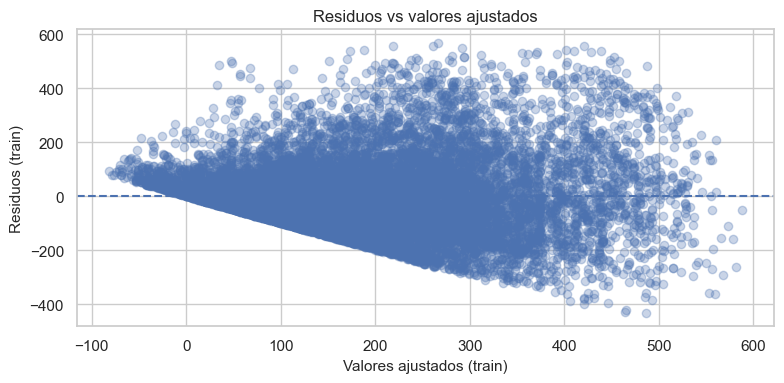

In [32]:
fig, ax = plt.subplots()
ax.scatter(y_pred_train, residuals_train, alpha=0.3)
ax.axhline(0, linestyle='--')
ax.set_xlabel("Valores ajustados (train)")
ax.set_ylabel("Residuos (train)")
ax.set_title("Residuos vs valores ajustados")
plt.tight_layout()
plt.show()

## 3. Normalidad de los residuos

Para evaluar la normalidad de los errores, analizamos:

- Histograma de los residuales.
- Gráfico Q–Q (cuantiles teóricos vs cuantiles observados).


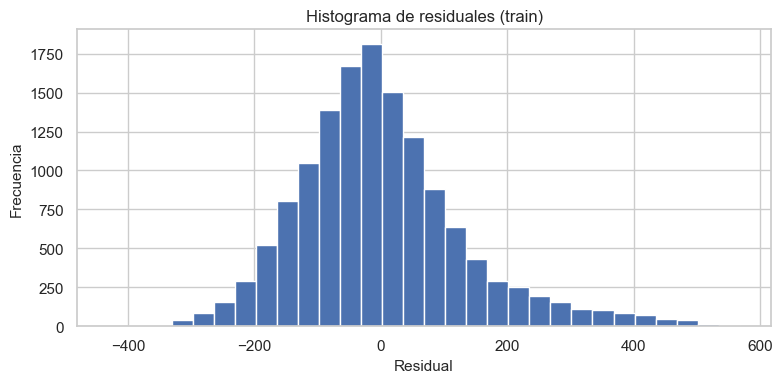

In [33]:
# Histograma de residuales
fig, ax = plt.subplots()
ax.hist(residuals_train, bins=30)
ax.set_title("Histograma de residuales (train)")
ax.set_xlabel("Residual")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

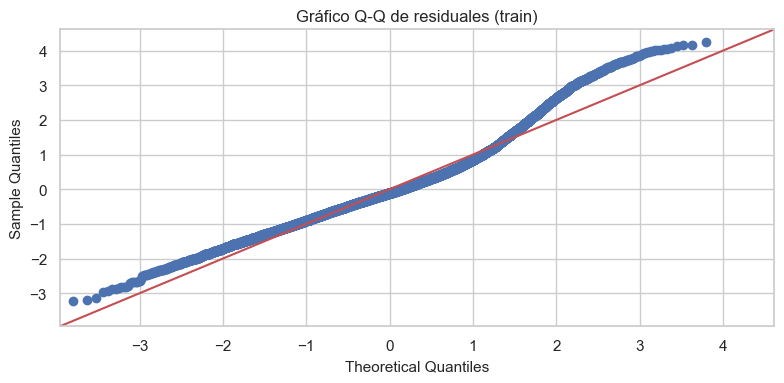

In [34]:
# Gráfico Q-Q de los residuales
fig = sm.ProbPlot(residuals_train, fit=True).qqplot(line='45')
plt.title("Gráfico Q-Q de residuales (train)")
plt.tight_layout()
plt.show()

## 4. Homocedasticidad: gráfico de escala-localización

El gráfico de **escala-localización** muestra la raíz cuadrada del valor absoluto de los residuales estandarizados frente a los valores ajustados. Permite detectar patrones de variabilidad creciente o decreciente.


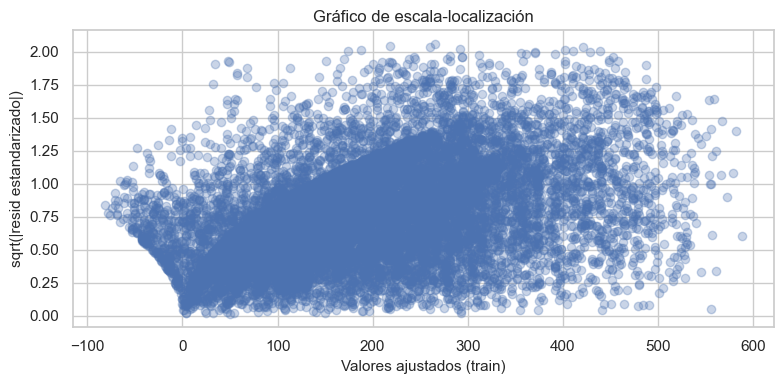

In [35]:
# Residuos estandarizados
influence = ols.get_influence()
standard_resid = influence.resid_studentized_internal

fig, ax = plt.subplots()
ax.scatter(y_pred_train, np.sqrt(np.abs(standard_resid)), alpha=0.3)
ax.set_xlabel("Valores ajustados (train)")
ax.set_ylabel("sqrt(|resid estandarizado|)")
ax.set_title("Gráfico de escala-localización")
plt.tight_layout()
plt.show()

## 5. Leverage y puntos influyentes

Utilizamos las medidas de influencia del modelo OLS para identificar posibles observaciones influyentes (alto leverage y/o alto impacto en los coeficientes).


In [36]:
# Leverage (h_ii) y medidas de influencia
influence = ols.get_influence()
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

pd.DataFrame({"leverage": leverage, "cooks_d": cooks_d}).describe()

,leverage,cooks_d
count,13903.000000,1.390300e+04
mean,0.000432,8.356576e-05
std,0.000797,4.786504e-04
min,0.000101,4.001227e-12
25%,0.000247,3.728742e-06
50%,0.000366,1.779748e-05
75%,0.000507,6.662216e-05
max,0.033749,3.343432e-02


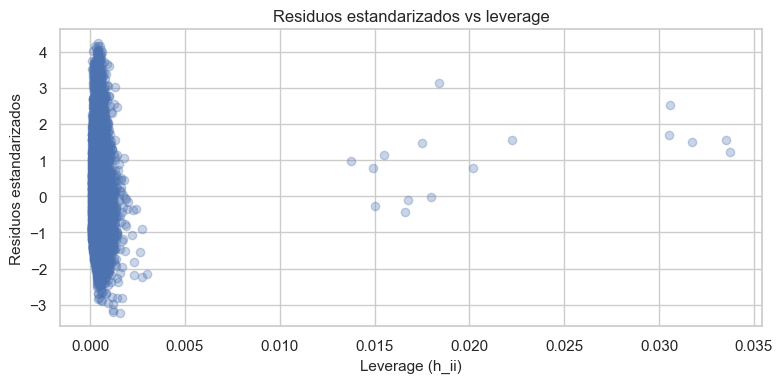

In [37]:
# Gráfico leverage vs residuales estandarizados
fig, ax = plt.subplots()
ax.scatter(leverage, standard_resid, alpha=0.3)
ax.set_xlabel("Leverage (h_ii)")
ax.set_ylabel("Residuos estandarizados")
ax.set_title("Residuos estandarizados vs leverage")
plt.tight_layout()
plt.show()

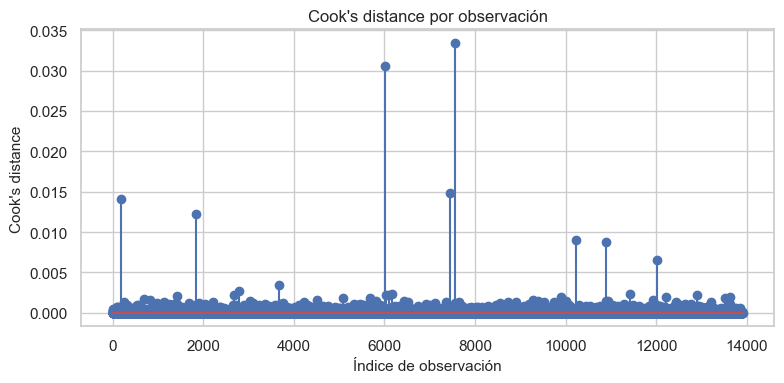

In [38]:
# Gráfico de Cook's distance
fig, ax = plt.subplots()
ax.stem(np.arange(len(cooks_d)), cooks_d)
ax.set_xlabel("Índice de observación")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's distance por observación")
plt.tight_layout()
plt.show()

## 6. Multicolinealidad: Factor de Inflación de la Varianza (VIF)

Para evaluar la presencia de **multicolinealidad** entre los predictores, calculamos el **Variance Inflation Factor (VIF)** para cada columna de `X_train`.

Valores de referencia típicos:

- VIF ≈ 1: sin colinealidad.
- 1–5: colinealidad moderada.
- > 5 (o > 10 según criterio): colinealidad alta.


In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculamos VIF sobre X_train (sin la columna de intercepto)
X_vif = X_train.copy()
vif_data = []
for i, col in enumerate(X_vif.columns):
    vif_val = variance_inflation_factor(X_vif.values, i)
    vif_data.append({"variable": col, "VIF": vif_val})

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
vif_df.reset_index(drop=True, inplace=True)
vif_df.round(2)

,variable,VIF
0,atemp,361.77
1,temp,335.19
2,hum,5.96
3,windspeed,2.76
4,peak_hour,1.33


## 7. Resumen del capítulo

En este capítulo realizamos un diagnóstico básico del modelo lineal:

- Graficamos **residuos vs valores ajustados** para evaluar linealidad y forma.
- Analizamos la **normalidad de los residuos** mediante histograma y gráfico Q–Q.
- Exploramos la **homocedasticidad** con un gráfico de escala-localización.
- Estudiamos **leverage** y **Cook's distance** para identificar observaciones influyentes.
- Calculamos el **VIF** para evaluar multicolinealidad entre predictores.

Estos resultados servirán de base para, en capítulos posteriores, considerar transformaciones, selección de variables y métodos más robustos o regularizados si los supuestos del modelo clásico no se cumplen adecuadamente.
